
--- Test 1: Time step convergence ---
True value v(0, [1,1]) = 2.371073

     N       tau    err_explicit    err_implicit
     1    1.0000      2.1864e+00      5.6302e-01
    10    0.1000      1.0288e-01      9.6092e-02
    50    0.0200      1.9109e-02      2.0514e-02
   100    0.0100      7.8914e-03      1.1940e-02
   500    0.0020      2.8229e-04      4.2481e-03
  1000    0.0010      1.0364e-03      3.0324e-03
  5000    0.0002      7.5912e-04      9.3579e-04
Saved exercise_1_2_timestep_convergence.png


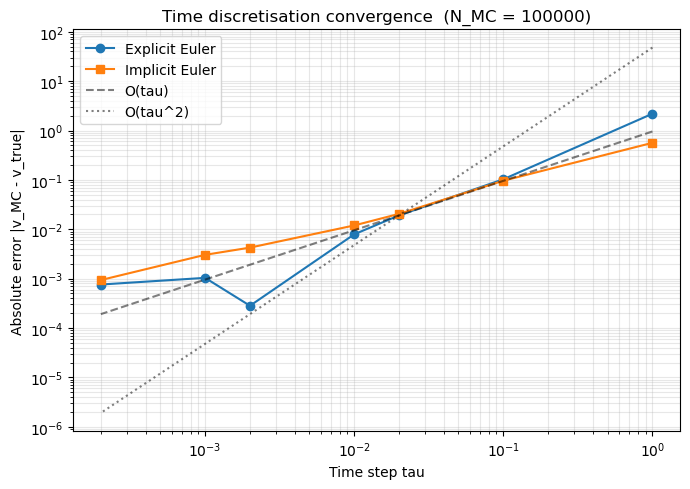


--- Test 2: MC sample convergence ---
True value v(0, [1,1]) = 2.371073

    N_MC        v_MC     std_err     |error|
      10     2.17776    1.44e-01    1.93e-01
      50     2.34658    8.61e-02    2.45e-02
     100     2.35144    5.94e-02    1.96e-02
     500     2.40881    2.77e-02    3.77e-02
    1000     2.36947    1.98e-02    1.61e-03
    5000     2.36000    8.72e-03    1.11e-02
   10000     2.36472    6.15e-03    6.35e-03
   50000     2.36779    2.77e-03    3.28e-03
  100000     2.37031    1.96e-03    7.59e-04
Saved exercise_1_2_mc_convergence.png


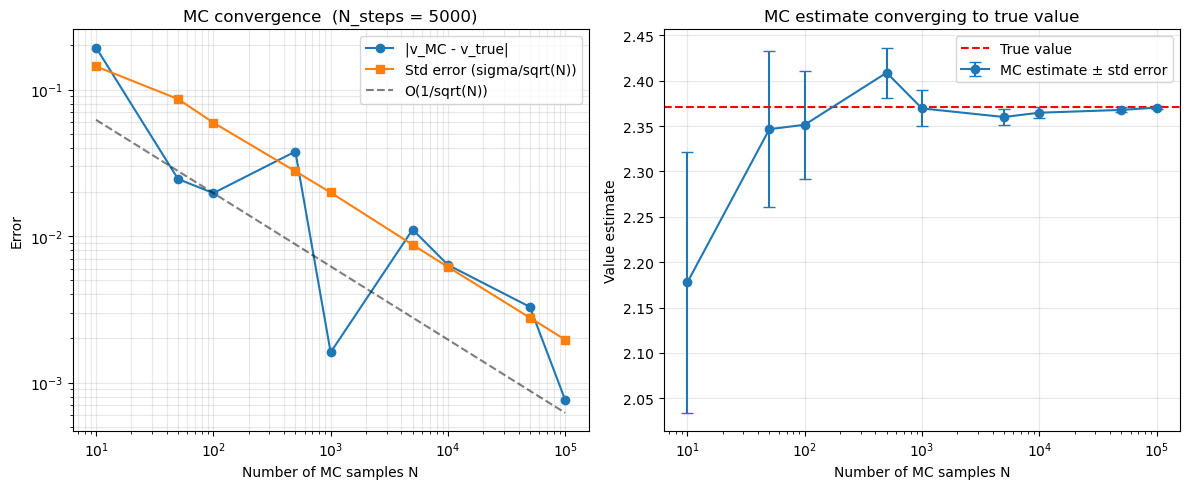

In [1]:
"""
Exercise 1.2 - Monte Carlo validation of the LQR solution

We simulate the optimally-controlled SDE using Euler schemes and check thatcthe average cost converges 
to the analytical value from Exercise 1.1.

In order to do this, we verify:
  1. Discretisation error -> 0 as tau -> 0 (fix N_MC large, vary N_steps)
  2. Statistical error -> 0 as N_MC -> inf (fix N_steps large, vary N_MC)

From NPMC we expect both to converge at rates O(tau) and O(1/sqrt(N_MC)).
"""

import numpy as np
import torch
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt


# -----------------------------------------------------------------------
# LQRSolver (copied from Ex 1.1 so this file runs standalone)
# -----------------------------------------------------------------------

class LQRSolver:
    """
    Solves the LQR problem via Riccati ODE.

    We want to minimise
        J(t,x) = E[ int_t^T (X'CX + a'Da) ds + X_T' R X_T ],
    subject to
        dX = (HX + Ma) dt + sigma dW,  X_t = x.

    The value function is
        v(t,x) = x'S(t)x + int_t^T tr(sigma sigma' S(r)) dr
    where S solves the Riccati ODE and the optimal control is
        a*(t,x) = -D^{-1} M' S(t) x.
    """

    def __init__(self, H, M, C, D, R, sigma, T):
        self.H = np.array(H, dtype=float)
        self.M = np.array(M, dtype=float)
        self.C = np.array(C, dtype=float)
        self.D = np.array(D, dtype=float)
        self.R = np.array(R, dtype=float)
        self.sigma = np.array(sigma, dtype=float)
        self.T = float(T)

        # precompute these since they're used a lot
        self.D_inv = np.linalg.inv(self.D)
        self.MD_invMT = self.M @ self.D_inv @ self.M.T

        self.S_interp = None
        self.integral_interp = None

    def _riccati_rhs(self, tau, S_flat):
        """
        RHS of the Riccati ODE in forward time tau = T - t.

        The ODE in original time is
            S'(t) = -2H'S + S M D^{-1} M' S - C,   S(T) = R.

        Substituting tau = T - t flips the sign, giving a standard forward IVP we can pass directly to solve_ivp:
            dS/dtau = 2H'S - S M D^{-1} M' S + C,   S(0) = R.
        """
        S = S_flat.reshape(2, 2)
        dS = 2 * self.H.T @ S - S @ self.MD_invMT @ S + self.C
        return dS.flatten()

    def solve_riccati(self, time_grid):
        """
        Solve the Riccati ODE on the given time grid and build interpolators for S(t) and the integral term.

        Args:
            time_grid: array of times in [0, T] (numpy or torch)

        Returns:
            S_values: array of shape (len(time_grid), 2, 2)
        """
        if isinstance(time_grid, torch.Tensor):
            time_grid = time_grid.cpu().numpy()
        time_grid = np.array(time_grid, dtype=float)

        # solve forward in tau = T - t, starting from S(T) = R
        tau_grid = self.T - time_grid  # decreasing in t -> increasing in tau
        sol = solve_ivp(
            self._riccati_rhs,
            (0.0, self.T),
            self.R.flatten(),
            t_eval=tau_grid[::-1],  # need increasing tau values
            method='RK45',
            rtol=1e-8,
            atol=1e-10
        )

        if not sol.success:
            raise RuntimeError(f"Riccati solve failed: {sol.message}")

        # reverse back so columns match increasing t
        S_values = sol.y[:, ::-1].T.reshape(-1, 2, 2)

        # build interpolator for S(t)
        self.S_interp = [
            [interp1d(time_grid, S_values[:, i, j], kind='cubic',
                      bounds_error=False, fill_value='extrapolate')
             for j in range(2)]
            for i in range(2)
        ]

        # compute integral term: int_t^T tr(sigma sigma' S(r)) dr
        # this is the noise-driven part of the value function (no x dependence)
        ss = self.sigma @ self.sigma.T
        trace_vals = np.array([np.trace(ss @ S) for S in S_values])

        # integrate backwards using the trapezoid rule
        integral = np.zeros(len(time_grid))
        for i in range(len(time_grid) - 2, -1, -1):
            dt = time_grid[i+1] - time_grid[i]
            integral[i] = integral[i+1] + 0.5 * dt * (trace_vals[i] + trace_vals[i+1])

        self.integral_interp = interp1d(time_grid, integral, kind='cubic',
                                        bounds_error=False, fill_value='extrapolate')

        return S_values

    def _get_S(self, t):
        """Evaluate S(t) at one or more times. Accepts numpy arrays or torch tensors."""
        if self.S_interp is None:
            raise RuntimeError("Call solve_riccati first")

        is_torch = isinstance(t, torch.Tensor)
        t_np = t.cpu().numpy() if is_torch else np.asarray(t, dtype=float)

        shape = t_np.shape
        t_flat = t_np.flatten()

        S_out = np.zeros((len(t_flat), 2, 2))
        for i in range(2):
            for j in range(2):
                S_out[:, i, j] = self.S_interp[i][j](t_flat)

        S_out = S_out.reshape(*shape, 2, 2)

        if is_torch:
            return torch.from_numpy(S_out).float().to(t.device)
        return S_out

    def value_function(self, t_batch, x_batch):
        """
        Compute v(t, x) = x' S(t) x + int_t^T tr(sigma sigma' S(r)) dr.

        Args:
            t_batch: torch tensor, shape (batch_size,)
            x_batch: torch tensor, shape (batch_size, 1, 2)

        Returns:
            v: torch tensor, shape (batch_size, 1)
        """
        if self.S_interp is None:
            raise RuntimeError("Call solve_riccati first")

        S = self._get_S(t_batch)  # (batch, 2, 2)
        x = x_batch.squeeze(1)   # (batch, 2)

        # quadratic form x' S(t) x
        xSx = torch.sum((x.unsqueeze(1) @ S).squeeze(1) * x, dim=1)

        # noise correction term (same for all x at a given t)
        integral_vals = torch.from_numpy(
            self.integral_interp(t_batch.cpu().numpy())
        ).float().to(t_batch.device)

        return (xSx + integral_vals).unsqueeze(1)

    def optimal_control(self, t_batch, x_batch):
        """
        Compute the optimal control a*(t, x) = -D^{-1} M' S(t) x.

        Args:
            t_batch: torch tensor, shape (batch_size,)
            x_batch: torch tensor, shape (batch_size, 1, 2)

        Returns:
            a: torch tensor, shape (batch_size, 2)
        """
        if self.S_interp is None:
            raise RuntimeError("Call solve_riccati first")

        S = self._get_S(t_batch)  # (batch, 2, 2)
        x = x_batch.squeeze(1)   # (batch, 2)

        neg_DinvMT = torch.from_numpy(-self.D_inv @ self.M.T).float().to(t_batch.device)

        # compute S(t) x then apply -D^{-1} M'
        Sx = (S @ x.unsqueeze(2)).squeeze(2)           # (batch, 2)
        a = (neg_DinvMT @ Sx.unsqueeze(2)).squeeze(2)  # (batch, 2)


class LQRMonteCarlo:
    """
    Monte Carlo simulation of the optimally-controlled LQR SDE.

    With the optimal control plugged in, the SDE becomes linear in X:
        dX = (H - M D^{-1} M' S(t)) X dt + sigma dW

    We implement explicit and implicit Euler schemes to discretise this.
    """

    def __init__(self, solver):
        self.solver = solver
        self.H = solver.H
        self.M = solver.M
        self.C = solver.C
        self.D = solver.D
        self.R = solver.R
        self.sigma = solver.sigma
        self.T = solver.T

    def _precompute_matrices(self, times):
        """Pre-evaluate S(t) at all time grid points to avoid repeated interpolator calls in the loop."""
        t_np = times.numpy() if isinstance(times, torch.Tensor) else times
        return self.solver._get_S(t_np)  # numpy array (n_steps+1, 2, 2)

    def simulate_explicit(self, t0, x0, n_steps, n_mc, seed=None):
        """
        Explicit Euler scheme:
            X_{n+1} = X_n + tau * (H - M D^{-1} M' S(t_n)) X_n + sigma * dW_n

        Running cost accumulated using X_n (left-endpoint rule).

        Returns array of shape (n_mc,) with total cost per path.
        """
        if seed is not None:
            np.random.seed(seed)
            torch.manual_seed(seed)

        tau = (self.T - t0) / n_steps
        times = np.linspace(t0, self.T, n_steps + 1)

        # precompute S on the whole grid
        S_all = self._precompute_matrices(times)  # (n_steps+1, 2, 2)

        H = torch.tensor(self.H, dtype=torch.float32)
        M = torch.tensor(self.M, dtype=torch.float32)
        C = torch.tensor(self.C, dtype=torch.float32)
        D = torch.tensor(self.D, dtype=torch.float32)
        R = torch.tensor(self.R, dtype=torch.float32)
        sig = torch.tensor(self.sigma, dtype=torch.float32)
        DinvMT = torch.tensor(self.solver.D_inv @ self.M.T, dtype=torch.float32)

        X = torch.tensor(x0, dtype=torch.float32).repeat(n_mc, 1)
        cost = torch.zeros(n_mc)

        for n in range(n_steps):
            S_n = torch.tensor(S_all[n], dtype=torch.float32)

            # effective drift matrix for the controlled SDE
            A = H - M @ DinvMT @ S_n

            # running cost: x'Cx + a'Da where a = -D^{-1} M' S x
            a_n = -(DinvMT @ S_n @ X.T).T
            state_cost = torch.sum((X @ C) * X, dim=1)
            ctrl_cost  = torch.sum((a_n @ D) * a_n, dim=1)
            cost += tau * (state_cost + ctrl_cost)

            # Euler step
            dW = torch.randn(n_mc, 2) * np.sqrt(tau)
            X = X + tau * (X @ A.T) + (sig @ dW.T).T

        # terminal cost
        cost += torch.sum((X @ R) * X, dim=1)
        return cost.numpy()

    def simulate_implicit(self, t0, x0, n_steps, n_mc, seed=None):
        """
        Implicit Euler scheme:
            X_{n+1} = X_n + tau * (H - M D^{-1} M' S(t_{n+1})) X_{n+1} + sigma * dW_n

        Rearranging gives a linear system:
            (I - tau * A_{n+1}) X_{n+1} = X_n + sigma * dW_n

        This is a 2x2 system, the same for all paths at a given step, so we can solve it efficiently for 
        all paths at once via torch.linalg.solve.

        Running cost accumulated using X_{n+1} (right-endpoint rule).
        """
        if seed is not None:
            np.random.seed(seed)
            torch.manual_seed(seed)

        tau = (self.T - t0) / n_steps
        times = np.linspace(t0, self.T, n_steps + 1)

        S_all = self._precompute_matrices(times)

        H = torch.tensor(self.H, dtype=torch.float32)
        M = torch.tensor(self.M, dtype=torch.float32)
        C = torch.tensor(self.C, dtype=torch.float32)
        D = torch.tensor(self.D, dtype=torch.float32)
        R = torch.tensor(self.R, dtype=torch.float32)
        sig = torch.tensor(self.sigma, dtype=torch.float32)
        DinvMT = torch.tensor(self.solver.D_inv @ self.M.T, dtype=torch.float32)
        I = torch.eye(2)

        X = torch.tensor(x0, dtype=torch.float32).repeat(n_mc, 1)
        cost = torch.zeros(n_mc)

        for n in range(n_steps):
            S_np1 = torch.tensor(S_all[n+1], dtype=torch.float32)
            A = H - M @ DinvMT @ S_np1

            # system matrix: same for all paths at this step
            sys_mat = I - tau * A  # (2, 2)

            dW = torch.randn(n_mc, 2) * np.sqrt(tau)
            rhs = X + (sig @ dW.T).T  # (n_mc, 2)

            # solve sys_mat @ X_new.T = rhs.T  ->  X_new.T = solve(sys_mat, rhs.T)
            X = torch.linalg.solve(sys_mat, rhs.T).T

            # running cost at t_{n+1}
            a_np1 = -(DinvMT @ S_np1 @ X.T).T
            state_cost = torch.sum((X @ C) * X, dim=1)
            ctrl_cost  = torch.sum((a_np1 @ D) * a_np1, dim=1)
            cost += tau * (state_cost + ctrl_cost)

        cost += torch.sum((X @ R) * X, dim=1)
        return cost.numpy()

    def estimate_value(self, t0, x0, n_steps, n_mc, method='explicit', seed=None):
        """Run simulation and return (mean estimate, standard error)."""
        if method == 'explicit':
            costs = self.simulate_explicit(t0, x0, n_steps, n_mc, seed)
        else:
            costs = self.simulate_implicit(t0, x0, n_steps, n_mc, seed)
        return np.mean(costs), np.std(costs) / np.sqrt(n_mc)


# -----------------------------------------------------------------------
# Convergence tests
# -----------------------------------------------------------------------

def setup_problem():
    H     = np.array([[0.1, 0.0], [0.0, 0.1]])
    M     = np.array([[1.0, 0.0], [0.0, 1.0]])
    C     = np.array([[1.0, 0.0], [0.0, 1.0]])
    D     = np.array([[1.0, 0.0], [0.0, 1.0]])
    R     = np.array([[1.0, 0.0], [0.0, 1.0]])
    sigma = np.array([[0.3, 0.0], [0.0, 0.3]])
    T     = 1.0

    solver = LQRSolver(H, M, C, D, R, sigma, T)
    solver.solve_riccati(np.linspace(0, T, 1000))
    return solver


def run_timestep_convergence(solver, n_mc=100_000):
    """
    Fix N_MC large and vary the number of time steps.
    We expect O(tau) convergence for both Euler schemes.

    Error measure: |E[cost] - v_true|
    """
    sim = LQRMonteCarlo(solver)
    t0, x0 = 0.0, np.array([1.0, 1.0])

    # true value from the Riccati solution
    v_true = solver.value_function(
        torch.tensor([t0]),
        torch.tensor([[[1.0, 1.0]]])
    )[0, 0].item()
    print(f"True value v(0, [1,1]) = {v_true:.6f}")

    n_steps_list = [1, 10, 50, 100, 500, 1000, 5000]
    errs_exp, errs_imp = [], []

    print(f"\n{'N':>6}  {'tau':>8}  {'err_explicit':>14}  {'err_implicit':>14}")
    for N in n_steps_list:
        tau = solver.T / N
        v_exp, _ = sim.estimate_value(t0, x0, N, n_mc, 'explicit', seed=0)
        v_imp, _ = sim.estimate_value(t0, x0, N, n_mc, 'implicit', seed=0)
        errs_exp.append(abs(v_exp - v_true))
        errs_imp.append(abs(v_imp - v_true))
        print(f"{N:>6}  {tau:>8.4f}  {errs_exp[-1]:>14.4e}  {errs_imp[-1]:>14.4e}")

    
    tau_vals = [solver.T / N for N in n_steps_list]
    tau_arr  = np.array(tau_vals)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.loglog(tau_vals, errs_exp, 'o-', label='Explicit Euler')
    ax.loglog(tau_vals, errs_imp, 's-', label='Implicit Euler')

    scale1 = errs_exp[2] / tau_arr[2]
    scale2 = errs_exp[2] / tau_arr[2]**2
    ax.loglog(tau_arr, scale1 * tau_arr,    'k--', alpha=0.5, label='O(tau)')
    ax.loglog(tau_arr, scale2 * tau_arr**2, 'k:',  alpha=0.5, label='O(tau^2)')

    ax.set_xlabel('Time step tau')
    ax.set_ylabel('Absolute error |v_MC - v_true|')
    ax.set_title(f'Time discretisation convergence  (N_MC = {n_mc})')
    ax.legend()
    ax.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.savefig('exercise_1_2_timestep_convergence.png', dpi=150, bbox_inches='tight')
    print("Saved exercise_1_2_timestep_convergence.png")
    plt.show()

    return errs_exp, errs_imp


def run_mc_sample_convergence(solver, n_steps=5000):
    """
    Fix the time step small (N=5000) and vary the number of MC samples.
    We expect O(1/sqrt(N_MC)) convergence from the CLT.

    The absolute error |v_MC - v_true| will look noisy on the log-log plot, the std error line is the cleaner indicator
    of the underlying convergence rate.
    """
    sim = LQRMonteCarlo(solver)
    t0, x0 = 0.0, np.array([1.0, 1.0])

    v_true = solver.value_function(
        torch.tensor([t0]),
        torch.tensor([[[1.0, 1.0]]])
    )[0, 0].item()
    print(f"True value v(0, [1,1]) = {v_true:.6f}")

    n_mc_list = [10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000]
    errors, std_errors, mc_means = [], [], []

    print(f"\n{'N_MC':>8}  {'v_MC':>10}  {'std_err':>10}  {'|error|':>10}")
    for n_mc in n_mc_list:
        v_mc, se = sim.estimate_value(t0, x0, n_steps, n_mc, 'explicit', seed=0)
        errors.append(abs(v_mc - v_true))
        std_errors.append(se)
        mc_means.append(v_mc)
        print(f"{n_mc:>8}  {v_mc:>10.5f}  {se:>10.2e}  {errors[-1]:>10.2e}")

    n_arr = np.array(n_mc_list, dtype=float)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # left panel: log-log error vs N_MC
    ax1.loglog(n_mc_list, errors,     'o-', label='|v_MC - v_true|')
    ax1.loglog(n_mc_list, std_errors, 's-', label='Std error (sigma/sqrt(N))')
    # scale reference line to data
    scale = errors[2] * np.sqrt(n_mc_list[2])
    ax1.loglog(n_arr, scale / np.sqrt(n_arr), 'k--', alpha=0.5, label='O(1/sqrt(N))')
    ax1.set_xlabel('Number of MC samples N')
    ax1.set_ylabel('Error')
    ax1.set_title(f'MC convergence  (N_steps = {n_steps})')
    ax1.legend()
    ax1.grid(True, alpha=0.3, which='both')

    # right panel: estimate with error bars converging to true value
    ax2.errorbar(n_mc_list, mc_means, yerr=std_errors, fmt='o-', capsize=4,
                 label='MC estimate ± std error')
    ax2.axhline(v_true, color='r', linestyle='--', label='True value')
    ax2.set_xscale('log')
    ax2.set_xlabel('Number of MC samples N')
    ax2.set_ylabel('Value estimate')
    ax2.set_title('MC estimate converging to true value')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('exercise_1_2_mc_convergence.png', dpi=150, bbox_inches='tight')
    print("Saved exercise_1_2_mc_convergence.png")
    plt.show()


if __name__ == "__main__":
    solver = setup_problem()

    print("\n--- Test 1: Time step convergence ---")
    run_timestep_convergence(solver, n_mc=100_000)

    print("\n--- Test 2: MC sample convergence ---")
    run_mc_sample_convergence(solver, n_steps=5000)